# Step 2.1 — LiDAR Ground Removal + Clustering (Upgraded) ✅

| | |
|---|---|
| **Input** | `output/step_1/lidar/<sample>/lidar_raw.npy` (N×7, from Step 1.3) |
| **Outputs** | `output/step_2/lidar/<sample>/lidar_ground.npy` — ground plane points |
| | `output/step_2/lidar/<sample>/lidar_nonground.npy` — obstacle points |
| | `output/step_2/lidar/<sample>/lidar_cluster_labels.npy` — exact DBSCAN label per non-ground point |
| | `output/step_2/lidar/<sample>/lidar_clusters.json` — centroid + point count per cluster |
| | `output/step_2/lidar_summary.csv` — cluster counts per sample |
| | `output/step_2/bev_<sample>.png` — before/after ground removal, saved automatically |
| **Used by** | Step 3.3 (LiDAR tracking), Step 4.1/4.4 (fusion) |

---

### Bugs fixed from the original

1. **`lidar_ground.npy` was computed but never saved.** Your own visualization cell (further down) already tried to load it and printed a warning that it was missing — this version saves it.
2. **Cluster visualization used a "crude match"** (`distance from centroid < 2.0`) instead of the real DBSCAN labels — this misassigns points for any object larger than ~2m or clusters closer than 2m apart. Now the exact `labels` array is saved and reused.
3. **Dead code removed** — a `KDTree(points)` object was built but never used; `DBSCAN(algorithm='kd_tree')` already builds its own internally.
4. **RANSAC switched to Open3D's `segment_plane()`** — faster and more robust than the manual Python loop. The manual version is kept in its own cell below purely as a reference implementation for explaining RANSAC in interviews.
5. **Named constants** for RANSAC and DBSCAN parameters — previously buried as function defaults.

In [1]:
import open3d as o3d

print(o3d.__version__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.19.0


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Verify config.py exists
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

if not Path("config.py").exists():
    raise FileNotFoundError(
        "config.py not found in this folder. Copy it from the repo root."
    )

from config import STEP1_DIR, STEP2_DIR

LIDAR_IN_DIR  = STEP1_DIR / "lidar"
LIDAR_OUT_DIR = STEP2_DIR / "lidar"
LIDAR_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not LIDAR_IN_DIR.exists():
    raise FileNotFoundError(f"Step 1.3 output not found at {LIDAR_IN_DIR} — run Step 1.3 first.")

print(f"✅ LIDAR_IN_DIR  : {LIDAR_IN_DIR}")
print(f"✅ LIDAR_OUT_DIR : {LIDAR_OUT_DIR}")

config.py loaded. PROJECT_ROOT = F:\Sensor fusion Research
DATA_ROOT   = F:\Sensor fusion Research\DATA SET\archive
OUTPUT_ROOT = F:\Sensor fusion Research\output
✅ LIDAR_IN_DIR  : F:\Sensor fusion Research\output\step_1\lidar
✅ LIDAR_OUT_DIR : F:\Sensor fusion Research\output\step_2\lidar


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Named constants (previously hardcoded as function defaults)
# ─────────────────────────────────────────────────────────────────

# RANSAC ground plane fitting
RANSAC_DISTANCE_THRESHOLD = 0.2    # metres — max distance from plane to count as ground
RANSAC_N_POINTS           = 3      # points sampled per iteration (minimum to define a plane)
RANSAC_NUM_ITERATIONS     = 100    # iterations to search for best-fit plane

# DBSCAN obstacle clustering
DBSCAN_EPS         = 0.7   # metres — max distance between points in the same cluster
DBSCAN_MIN_SAMPLES = 10    # minimum points to form a cluster

print("✅ Constants set:")
print(f"   RANSAC: distance_threshold={RANSAC_DISTANCE_THRESHOLD}m, "
      f"n_points={RANSAC_N_POINTS}, iterations={RANSAC_NUM_ITERATIONS}")
print(f"   DBSCAN: eps={DBSCAN_EPS}m, min_samples={DBSCAN_MIN_SAMPLES}")

✅ Constants set:
   RANSAC: distance_threshold=0.2m, n_points=3, iterations=100
   DBSCAN: eps=0.7m, min_samples=10


## Reference implementation — manual RANSAC (for explaining the algorithm, not used in the pipeline)

Keep this for interviews: it shows you understand RANSAC from first principles. The actual pipeline below uses Open3D's optimized `segment_plane()` instead, which does the same thing faster and with better-tested edge case handling.

In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Reference only: manual RANSAC (NOT called by the pipeline)
# ─────────────────────────────────────────────────────────────────

import numpy as np

def remove_ground_ransac_manual(points, threshold=RANSAC_DISTANCE_THRESHOLD,
                                  max_iterations=RANSAC_NUM_ITERATIONS):
    """
    Manual RANSAC plane fitting — kept for reference / interview explanation.
    Algorithm: repeatedly sample 3 random points, fit a plane through them,
    count inliers within `threshold` distance, keep the best plane found.
    """
    max_inliers = []
    N = len(points)

    for _ in range(max_iterations):
        sample = points[np.random.choice(N, 3, replace=False)]
        v1, v2 = sample[1] - sample[0], sample[2] - sample[0]
        normal = np.cross(v1, v2)
        if np.linalg.norm(normal) == 0:
            continue
        normal = normal / np.linalg.norm(normal)
        d = -np.dot(normal, sample[0])

        distances = np.abs(points @ normal + d)
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(max_inliers):
            max_inliers = inliers

    ground_pts = points[max_inliers]
    non_ground_pts = np.delete(points, max_inliers, axis=0)
    return ground_pts, non_ground_pts

print("✅ Reference function defined (not used in the pipeline below).")

✅ Reference function defined (not used in the pipeline below).


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Main pipeline: ground removal (Open3D) + clustering (DBSCAN)
# FIXED: saves lidar_ground.npy (was missing)
# FIXED: saves exact cluster labels (removes the "crude match" hack)
# FIXED: dead KDTree object removed
# FIXED (optional): filter out clusters the wrong size/shape to be a
#        vehicle or pedestrian (too flat, too tall, too long and thin) --
#        walls, hedges, and curb fragments were being kept as "objects"
# FIXED: tracks skipped samples (missing lidar_raw.npy), same pattern as
#        Step 1.3, instead of silently continuing past them
# ─────────────────────────────────────────────────────────────────

import json
import numpy as np
import open3d as o3d
from sklearn.cluster import DBSCAN
from tqdm import tqdm


# Plausible vehicle/pedestrian bounding-box shape -- see CELL 4 header.
CLUSTER_MIN_HEIGHT_M = 0.4            # below this: road paint, curb, flat debris
CLUSTER_MAX_HEIGHT_M = 4.5            # above this: building/pole fragment (allows buses/trucks)
CLUSTER_MAX_HORIZONTAL_EXTENT_M = 15.0  # wider/longer than this: not a single object
CLUSTER_MAX_ASPECT_RATIO = 8.0        # long/short horizontal ratio above this: wall/hedge/guardrail segment


def remove_ground_open3d(points, distance_threshold, ransac_n, num_iterations):
    """Ground removal using Open3D's optimized RANSAC plane segmentation."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    plane_model, inlier_idx = pcd.segment_plane(
        distance_threshold=distance_threshold,
        ransac_n=ransac_n,
        num_iterations=num_iterations
    )

    inlier_idx = np.array(inlier_idx)
    mask = np.zeros(len(points), dtype=bool)
    mask[inlier_idx] = True

    ground_pts = points[mask]
    non_ground_pts = points[~mask]
    return ground_pts, non_ground_pts


def cluster_points(points, eps, min_samples):
    """DBSCAN handles its own KD-tree acceleration internally via algorithm='kd_tree'."""
    db = DBSCAN(eps=eps, min_samples=min_samples, algorithm='kd_tree', metric='euclidean')
    return db.fit_predict(points)


sample_folders = sorted(LIDAR_IN_DIR.glob("sample_*"))
summary_rows = []
skipped_samples = []

for sample_folder in tqdm(sample_folders, desc="Processing LiDAR"):
    sample_id = sample_folder.name
    out_dir = LIDAR_OUT_DIR / sample_id
    out_dir.mkdir(parents=True, exist_ok=True)

    lidar_path = sample_folder / "lidar_raw.npy"
    if not lidar_path.exists():
        skipped_samples.append(sample_id)
        continue

    pts = np.load(lidar_path)[:, :3]   # x, y, z only (columns 3-6 are intensity/distance/azimuth/elevation)

    # ── Ground removal ──
    ground, non_ground = remove_ground_open3d(
        pts, RANSAC_DISTANCE_THRESHOLD, RANSAC_N_POINTS, RANSAC_NUM_ITERATIONS
    )
    np.save(out_dir / "lidar_ground.npy", ground)        # FIXED — was never saved before
    np.save(out_dir / "lidar_nonground.npy", non_ground)

    # ── Clustering ──
    if len(non_ground) >= DBSCAN_MIN_SAMPLES:
        labels = cluster_points(non_ground, DBSCAN_EPS, DBSCAN_MIN_SAMPLES)
    else:
        labels = np.full(len(non_ground), -1)  # too few points to cluster

    # FIXED — save exact labels, aligned index-for-index with lidar_nonground.npy
    np.save(out_dir / "lidar_cluster_labels.npy", labels)

    clusters = {}
    n_discarded_shape = 0
    for cluster_id in np.unique(labels):
        if cluster_id == -1:
            continue  # DBSCAN noise label
        cluster_pts = non_ground[labels == cluster_id]
        extent = (cluster_pts.max(axis=0) - cluster_pts.min(axis=0))
        dx, dy, dz = float(extent[0]), float(extent[1]), float(extent[2])
        horiz_max, horiz_min = max(dx, dy), max(min(dx, dy), 1e-6)

        # FIXED (optional): discard clusters the wrong size/shape to plausibly
        # be a vehicle or pedestrian -- flat road-surface remnants, curbs, or
        # long thin wall/hedge/guardrail segments that survived ground removal.
        if (dz < CLUSTER_MIN_HEIGHT_M or dz > CLUSTER_MAX_HEIGHT_M
                or horiz_max > CLUSTER_MAX_HORIZONTAL_EXTENT_M
                or horiz_max / horiz_min > CLUSTER_MAX_ASPECT_RATIO):
            n_discarded_shape += 1
            continue

        clusters[str(int(cluster_id))] = {
            "num_points": int(len(cluster_pts)),
            "centroid": cluster_pts.mean(axis=0).tolist(),
            "extent": [dx, dy, dz]
        }

    with open(out_dir / "lidar_clusters.json", "w") as f:
        json.dump(clusters, f, indent=2)

    summary_rows.append({
        "sample_id": sample_id,
        "num_raw_points": len(pts),
        "num_ground_points": len(ground),
        "num_nonground_points": len(non_ground),
        "num_clusters": len(clusters),
        "num_noise_points": int((labels == -1).sum()),
        "num_discarded_shape": n_discarded_shape
    })

assert len(summary_rows) > 0, "No samples processed — check LIDAR_IN_DIR"

if skipped_samples:
    print(f"⚠️ {len(skipped_samples)} samples skipped (no lidar_raw.npy): {skipped_samples[:5]}...")

print(f"\n✅ Step 2.1 complete: {len(summary_rows)} samples processed.")
print(f"📄 Outputs in: {LIDAR_OUT_DIR}")


Processing LiDAR:   0%|          | 0/404 [00:00<?, ?it/s]

Processing LiDAR:   0%|          | 1/404 [00:01<07:33,  1.12s/it]

Processing LiDAR:   0%|          | 2/404 [00:02<06:43,  1.00s/it]

Processing LiDAR:   1%|          | 3/404 [00:02<06:24,  1.04it/s]

Processing LiDAR:   1%|          | 4/404 [00:03<06:20,  1.05it/s]

...

Processing LiDAR: 100%|█████████▉| 402/404 [05:59<00:01,  1.42it/s]

Processing LiDAR: 100%|█████████▉| 403/404 [05:59<00:00,  1.41it/s]

Processing LiDAR: 100%|██████████| 404/404 [06:00<00:00,  1.40it/s]

Processing LiDAR: 100%|██████████| 404/404 [06:00<00:00,  1.12it/s]


✅ Step 2.1 complete: 404 samples processed.
📄 Outputs in: F:\Sensor fusion Research\output\step_2\lidar


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Summary CSV + sanity checks
# FIXED: strengthened completion assertion — cross-checks against Step 1.3's
#        own row count (accounting for anything Step 2.1 itself skipped),
#        instead of only checking summary_rows is non-empty.
# ─────────────────────────────────────────────────────────────────

import pandas as pd

summary_df = pd.DataFrame(summary_rows)
summary_path = STEP2_DIR / "lidar_summary.csv"
summary_df.to_csv(summary_path, index=False)

expected_count = len(pd.read_csv(STEP1_DIR / "lidar_summary.csv"))
assert len(summary_rows) == expected_count - len(skipped_samples), \
    f"Expected {expected_count - len(skipped_samples)} samples, got {len(summary_rows)}"

zero_cluster_samples = summary_df[summary_df["num_clusters"] == 0]

print(f"✅ Summary saved: {summary_path}")
print(f"   Avg clusters/sample : {summary_df['num_clusters'].mean():.1f}")
print(f"   Avg ground points   : {summary_df['num_ground_points'].mean():.0f}")
print(f"   Avg non-ground points: {summary_df['num_nonground_points'].mean():.0f}")
print(f"   Ground-point ratio  : {summary_df['num_ground_points'].sum() / summary_df['num_raw_points'].sum() * 100:.1f}%")

if len(zero_cluster_samples) > 0:
    print(f"\n⚠️ {len(zero_cluster_samples)} samples produced ZERO clusters — worth checking:")
    print(zero_cluster_samples['sample_id'].tolist()[:10])

display(summary_df.head())


✅ Summary saved: F:\Sensor fusion Research\output\step_2\lidar_summary.csv
   Avg clusters/sample : 44.2
   Avg ground points   : 13292
   Avg non-ground points: 21427
   Ground-point ratio  : 38.3%


,sample_id,num_raw_points,num_ground_points,num_nonground_points,num_clusters,num_noise_points,num_discarded_shape
0,sample_0000,34688,13595,21093,33,4210,36
1,sample_0001,34720,14244,20476,23,4296,24
2,sample_0002,34720,14809,19911,33,4026,24
3,sample_0003,34688,12540,22148,39,3888,19
4,sample_0004,34752,11806,22946,42,3563,23


## Bird's-Eye-View visualization — auto-saves PNG (no interactive window needed)

Open3D's `draw_geometries()` opens an interactive 3D window that won't render in a saved notebook, a GitHub README, or a headless server. This matplotlib version saves a static top-down image automatically — this is what you want for your portfolio/README.

C:\Users\DS\AppData\Local\Temp\ipykernel_17660\114111205.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', max(len(unique_labels), 1))


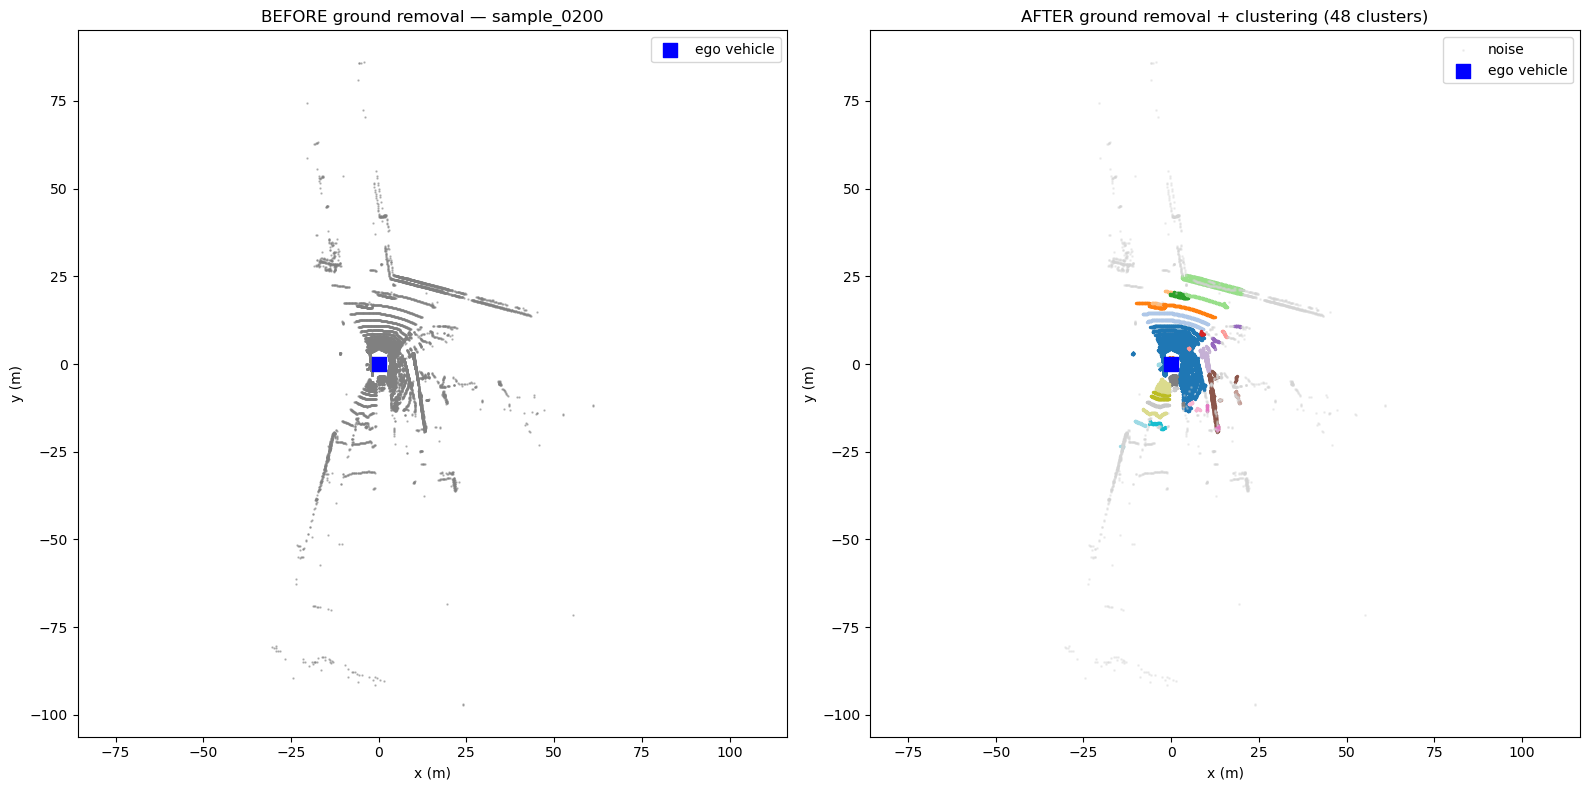

📄 Saved: F:\Sensor fusion Research\output\step_2\bev_sample_0200.png


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — Matplotlib BEV: before/after ground removal + clustering
# Uses the REAL cluster labels now, not the old "crude match"
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.cm as cm

sample_id = "sample_0200"   # ← change to visualize any sample
sample_dir = LIDAR_OUT_DIR / sample_id

raw_pts = np.load(LIDAR_IN_DIR / sample_id / "lidar_raw.npy")[:, :3]
non_ground = np.load(sample_dir / "lidar_nonground.npy")
labels = np.load(sample_dir / "lidar_cluster_labels.npy")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# BEFORE — all raw points
axes[0].scatter(raw_pts[:, 0], raw_pts[:, 1], s=0.5, c='gray', alpha=0.5)
axes[0].scatter(0, 0, c='blue', s=100, marker='s', label='ego vehicle')
axes[0].set_title(f"BEFORE ground removal — {sample_id}")
axes[0].set_xlabel("x (m)"); axes[0].set_ylabel("y (m)")
axes[0].legend(); axes[0].axis('equal')

# AFTER — clusters colored by their REAL DBSCAN label
unique_labels = [l for l in np.unique(labels) if l != -1]
colors = cm.get_cmap('tab20', max(len(unique_labels), 1))

for i, cluster_id in enumerate(unique_labels):
    cluster_pts = non_ground[labels == cluster_id]
    axes[1].scatter(cluster_pts[:, 0], cluster_pts[:, 1], s=2, color=colors(i))

noise_pts = non_ground[labels == -1]
if len(noise_pts) > 0:
    axes[1].scatter(noise_pts[:, 0], noise_pts[:, 1], s=1, c='lightgray', alpha=0.3, label='noise')

axes[1].scatter(0, 0, c='blue', s=100, marker='s', label='ego vehicle')
axes[1].set_title(f"AFTER ground removal + clustering ({len(unique_labels)} clusters)")
axes[1].set_xlabel("x (m)"); axes[1].set_ylabel("y (m)")
axes[1].legend(); axes[1].axis('equal')

plt.tight_layout()
save_path = STEP2_DIR / f"bev_{sample_id}.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"📄 Saved: {save_path}")

## Optional — interactive 3D view (Open3D window, not saved automatically)

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Optional: interactive Open3D 3D viewer
# FIXED: uses real labels instead of the crude distance-based match
# ─────────────────────────────────────────────────────────────────

import random

pcd = o3d.geometry.PointCloud()
colors = []

for cluster_id in unique_labels:
    cluster_pts = non_ground[labels == cluster_id]   # EXACT membership, not a distance guess
    color = [random.random(), random.random(), random.random()]
    pcd.points.extend(o3d.utility.Vector3dVector(cluster_pts))
    colors.extend([color] * len(cluster_pts))

pcd.colors = o3d.utility.Vector3dVector(np.array(colors))

print(f"Showing LiDAR clusters for {sample_id}... (close window to continue)")
o3d.visualization.draw_geometries([pcd])

Showing LiDAR clusters for sample_0200... (close window to continue)
